In [37]:
from luminis_mc import load_sweep_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [38]:
def max_theta_cbs(anisotropy, wavelength, meanfreepath) -> float:
    in_radians = wavelength * (1 - anisotropy) / (2 * np.pi * meanfreepath)
    return np.degrees(in_radians)

Loading sweep data...
  [warn] order 2 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 3 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 4 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 5 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 7 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 10 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 15 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously open object (component not found)'
  [warn] order 20 not found in 0000_radius_0.070_mfp_121.3_ms_0.0: 'Unable to synchronously op

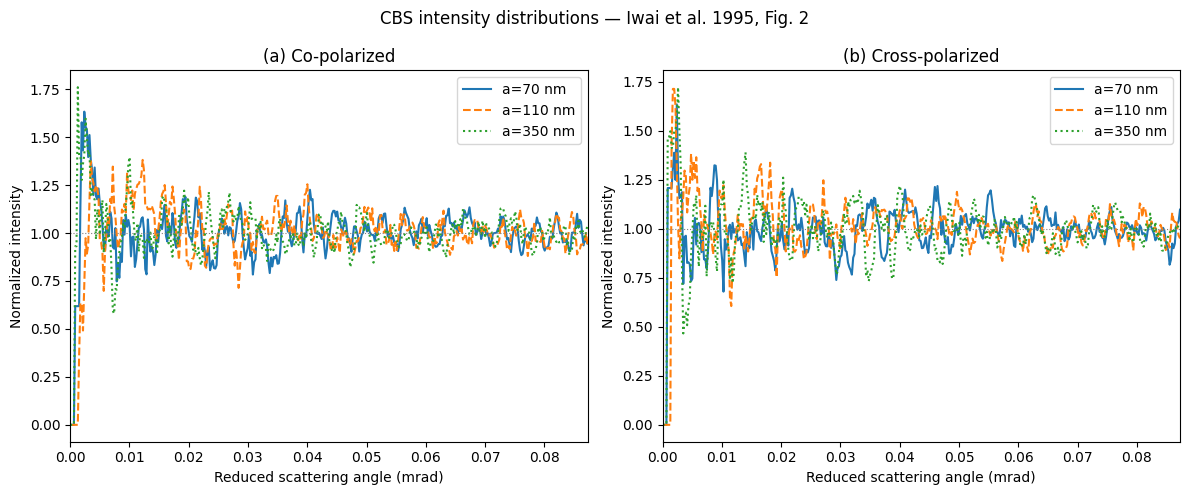

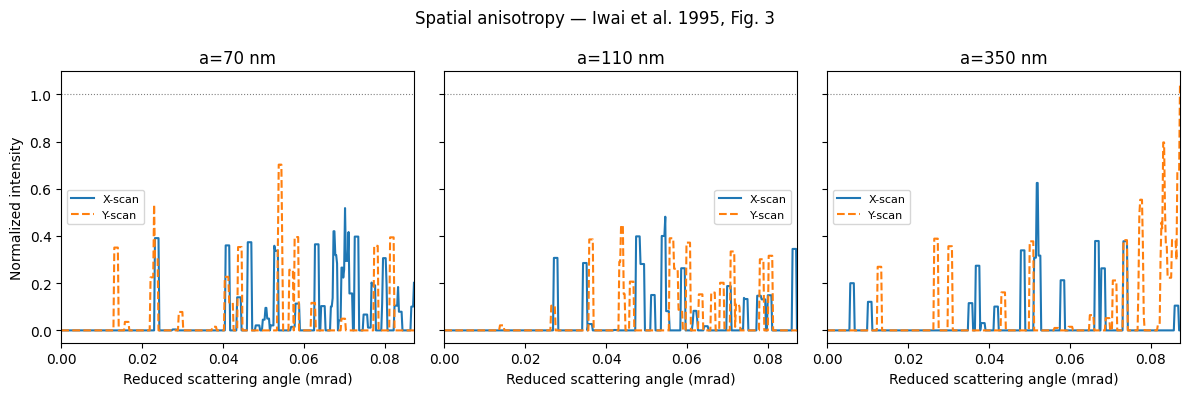

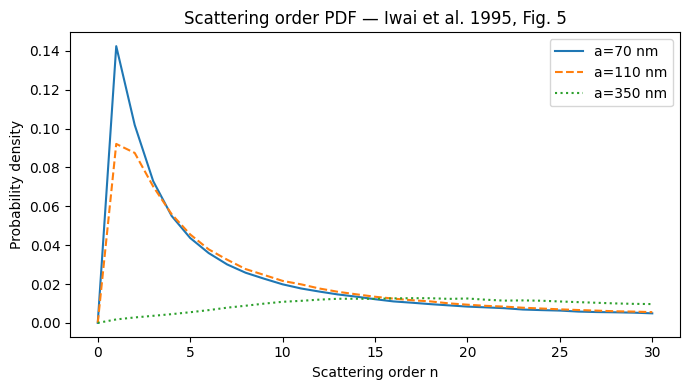

In [2]:
"""
load_cbs_rgd.py
───────────────
Loader and analyser for CBS Rayleigh-Debye sweep results.
Replicates Iwai et al. 1995 figures from luminis-mc HDF5 output.

Data layout expected on disk (from simulation script):
    <sweep_dir>/runs/
    ├── 0000_Rayleigh/results.h5
    ├── 0001_a70nm/results.h5
    ├── 0002_a110nm/results.h5
    └── 0003_a350nm/results.h5

Each results.h5 contains derived/:
    axes/theta_mrad, axes/phi_rad
    farfield_cbs/coherent/s0..s3
    farfield_cbs/incoherent/s0..s3
    order_02/coherent/s0..s3   (per-order, per-run)
    ...
And sensors/:
    statistics  (events, theta, depth histograms)
"""

import os
import numpy as np
from scipy.ndimage import uniform_filter1d
from luminis_mc import load_sweep_data   # or however your sweep loader is imported


# ─────────────────────────────────────────────────────────────────────────────
# 1.  Run descriptors
#     One dict per simulation run, matching the run_name used in sweep.run()
# ─────────────────────────────────────────────────────────────────────────────

SCATTERING_ORDERS_SMALL = [2, 3, 4, 5, 7, 10, 15, 20, 50]          # Rayleigh, a=70, a=110
SCATTERING_ORDERS_LARGE = [2, 3, 4, 5, 7, 10, 15, 20, 50]          # a=350

RUN_DESCRIPTORS = [
    {
        "run_name":  "0000_radius_0.070_mfp_121.3_ms_0.0",
        "label":     "a=70 nm",
        "radius_um": 0.070,
        "mfp_um":    121.3,
        "orders":    SCATTERING_ORDERS_SMALL,
        "axes": {}, "total": {}, "aniso": {}, "orders_data": {}, "stats": {}, "params": {},
    },
    {
        "run_name":  "0001_radius_0.110_mfp_34.6_ms_0.0",
        "label":     "a=110 nm",
        "radius_um": 0.110,
        "mfp_um":    34.6,
        "orders":    SCATTERING_ORDERS_SMALL,
        "axes": {}, "total": {}, "aniso": {}, "orders_data": {}, "stats": {}, "params": {},
    },
    {
        "run_name":  "0002_radius_0.350_mfp_4.9_ms_0.2",
        "label":     "a=350 nm",
        "radius_um": 0.350,
        "mfp_um":    4.9,
        "orders":    SCATTERING_ORDERS_LARGE,
        "axes": {}, "total": {}, "aniso": {}, "orders_data": {}, "stats": {}, "params": {},
    },
]


# ─────────────────────────────────────────────────────────────────────────────
# 2.  Stokes → polarization channels
#
#     Incident light: linearly polarized along X  →  Jones vector (1, 0)
#
#     S0 = |Ex|² + |Ey|²   (total intensity)
#     S1 = |Ex|² − |Ey|²   (X vs Y linear)
#     S2 = 2 Re(Ex Ey*)
#     S3 = 2 Im(Ex Ey*)    (circular — NOT used for linear incident)
#
#     Co-polarized   (X-analyzer, parallel to incident):
#         I_co    = (S0 + S1) / 2  = |Ex|²
#
#     Cross-polarized (Y-analyzer, perpendicular to incident):
#         I_cross = (S0 − S1) / 2  = |Ey|²
#
#     NOTE: your layered-media code uses (S0 ± S3)/2 which is for
#     CIRCULAR incident polarization. For linear X-polarized light
#     (this paper) use S1, not S3.
# ─────────────────────────────────────────────────────────────────────────────

def stokes_to_copol(S0, S1):
    """Co-polarized intensity (X-analyzer). Shape preserved."""
    return (S0 + S1) / 2.0

def stokes_to_crosspol(S0, S1):
    """Cross-polarized intensity (Y-analyzer). Shape preserved."""
    return (S0 - S1) / 2.0

def smooth(arr, size=5):
    """5-point moving average along axis=0 (theta axis). Matches paper."""
    return uniform_filter1d(arr.astype(float), size=size, axis=0)


# ─────────────────────────────────────────────────────────────────────────────
# 3.  Core loader for a single run
# ─────────────────────────────────────────────────────────────────────────────

def _phi_idx(phi_rad_array, target_deg):
    """Return the bin index closest to target_deg degrees."""
    target_rad = np.deg2rad(target_deg)
    return int(np.argmin(np.abs(phi_rad_array - target_rad)))

def _load_stokes_pair(layer, base_key):
    """
    Load S0..S3 coherent and incoherent from derived storage.
    Returns (S0_c, S1_c, S0_i, S1_i)  shape: (N_theta, N_phi)
    """
    S0_c = layer.derived(f"{base_key}/coherent/s0")
    S1_c = layer.derived(f"{base_key}/coherent/s1")
    S0_i = layer.derived(f"{base_key}/incoherent/s0")
    S1_i = layer.derived(f"{base_key}/incoherent/s1")
    return S0_c, S1_c, S0_i, S1_i

def _compute_channels(S0_c, S1_c, S0_i, S1_i, phi_arr, smooth_size=5):
    """
    From raw 2D Stokes (N_theta × N_phi) compute:
      - radial (phi-averaged) co and cross pol, coherent and incoherent
      - enhancement (eta = coh / incoh)
      - phi slices at 0° (X-scan) and 90° (Y-scan) for anisotropy
    All 1D arrays have shape (N_theta,).
    """
    co_c_2d    = stokes_to_copol(S0_c, S1_c)      # (N_theta, N_phi)
    cross_c_2d = stokes_to_crosspol(S0_c, S1_c)
    co_i_2d    = stokes_to_copol(S0_i, S1_i)
    cross_i_2d = stokes_to_crosspol(S0_i, S1_i)

    # --- Radial (phi-averaged) profiles ---
    co_c    = smooth(np.mean(co_c_2d,    axis=1), smooth_size)
    cross_c = smooth(np.mean(cross_c_2d, axis=1), smooth_size)
    co_i    = smooth(np.mean(co_i_2d,    axis=1), smooth_size)
    cross_i = smooth(np.mean(cross_i_2d, axis=1), smooth_size)

    eta_co    = co_c    / np.where(co_i    > 0, co_i,    1e-30)
    eta_cross = cross_c / np.where(cross_i > 0, cross_i, 1e-30)

    # --- Phi-slice profiles (spatial anisotropy, Fig. 3) ---
    ix = _phi_idx(phi_arr, 0.0)    # phi = 0°  → X-scan direction
    iy = _phi_idx(phi_arr, 90.0)   # phi = 90° → Y-scan direction

    co_c_X    = smooth(co_c_2d[:,  ix] / np.where(co_i_2d[:,  ix] > 0, co_i_2d[:,  ix], 1e-30), smooth_size)
    co_c_Y    = smooth(co_c_2d[:,  iy] / np.where(co_i_2d[:,  iy] > 0, co_i_2d[:,  iy], 1e-30), smooth_size)
    cross_c_X = smooth(cross_c_2d[:,ix] / np.where(cross_i_2d[:,ix] > 0, cross_i_2d[:,ix], 1e-30), smooth_size)
    cross_c_Y = smooth(cross_c_2d[:,iy] / np.where(cross_i_2d[:,iy] > 0, cross_i_2d[:,iy], 1e-30), smooth_size)

    return {
        # radial
        "co_coh":          co_c,
        "co_inc":          co_i,
        "co_eta":          eta_co,
        "cross_coh":       cross_c,
        "cross_inc":       cross_i,
        "cross_eta":       eta_cross,
        # phi slices for anisotropy
        "co_eta_X":        co_c_X,
        "co_eta_Y":        co_c_Y,
        "cross_eta_X":     cross_c_X,
        "cross_eta_Y":     cross_c_Y,
        # raw 2D (keep for custom slicing)
        "co_coh_2d":       co_c_2d,
        "cross_coh_2d":    cross_c_2d,
        "co_inc_2d":       co_i_2d,
        "cross_inc_2d":    cross_i_2d,
    }


def load_run(sweep_data, descriptor):
    """
    Load all data for one run into the descriptor dict.
    Modifies descriptor in-place, returns it.
    """
    run  = sweep_data[descriptor["run_name"]]
    desc = descriptor

    # ── Params ──────────────────────────────────────────────────────────────
    desc["params"] = run.params

    # ── Axes ────────────────────────────────────────────────────────────────
    theta_mrad = run.derived("axes/theta_mrad")   # shape (N_theta,)
    phi_rad    = run.derived("axes/phi_rad")       # shape (N_phi,)
    desc["axes"]["theta_mrad"] = theta_mrad
    desc["axes"]["phi_rad"]    = phi_rad

    # ── Total CBS ───────────────────────────────────────────────────────────
    S0_c, S1_c, S0_i, S1_i = _load_stokes_pair(run, "farfield_cbs")
    channels = _compute_channels(S0_c, S1_c, S0_i, S1_i, phi_rad)

    desc["total"] = {k: v for k, v in channels.items() if "_2d" not in k}
    desc["aniso"] = {
        "co_X":    channels["co_eta_X"],
        "co_Y":    channels["co_eta_Y"],
        "cross_X": channels["cross_eta_X"],
        "cross_Y": channels["cross_eta_Y"],
    }
    # keep 2D separately for custom analysis
    desc["total_2d"] = {k: v for k, v in channels.items() if "_2d" in k}

    # ── Per-order CBS (Fig. 4 and 5) ────────────────────────────────────────
    for order in desc["orders"]:
        key = f"order_{order:02d}"
        try:
            S0_c, S1_c, S0_i, S1_i = _load_stokes_pair(run, key)
            ch = _compute_channels(S0_c, S1_c, S0_i, S1_i, phi_rad)
            desc["orders_data"][order] = {k: v for k, v in ch.items() if "_2d" not in k}
        except Exception as e:
            print(f"  [warn] order {order} not found in {desc['run_name']}: {e}")
            desc["orders_data"][order] = None

    # ── Statistics histograms ────────────────────────────────────────────────
    try:
        meta = run.sensor_meta("statistics")
        desc["stats"]["events_hist"] = run.sensor_data("statistics", "events_histogram")
        desc["stats"]["depth_hist"]  = run.sensor_data("statistics", "depth_histogram")
        desc["stats"]["theta_hist"]  = run.sensor_data("statistics", "theta_histogram")
        desc["stats"]["meta"]        = meta

        # Build axes for histograms
        n_events = int(meta.get("max_events", len(desc["stats"]["events_hist"])))
        desc["stats"]["events_axis"] = np.arange(n_events)

        ddepth = meta.get("ddepth", 1.0)
        n_depth = len(desc["stats"]["depth_hist"])
        desc["stats"]["depth_axis"]  = np.arange(n_depth) * ddepth

        dtheta = meta.get("dtheta", 1.0)
        n_theta_hist = len(desc["stats"]["theta_hist"])
        desc["stats"]["theta_axis_hist"] = np.arange(n_theta_hist) * dtheta
    except Exception as e:
        print(f"  [warn] statistics not loaded for {desc['run_name']}: {e}")

    print(f"Loaded: {desc['run_name']}  ({desc['label']})")
    return desc


def load_all(sweep_path, descriptors=RUN_DESCRIPTORS):
    """Load the full sweep. Returns the list of filled descriptors."""
    from luminis_mc import load_sweep_data
    sweep_data = load_sweep_data(sweep_path)
    for desc in descriptors:
        load_run(sweep_data, desc)
    return descriptors


# ─────────────────────────────────────────────────────────────────────────────
# 4.  Helper accessors (convenience, avoid repeating dict drilling)
# ─────────────────────────────────────────────────────────────────────────────

def get_theta(desc):
    return desc["axes"]["theta_mrad"]

def get_total(desc, channel="co", part="eta"):
    """channel: 'co' or 'cross'.  part: 'coh', 'inc', 'eta'."""
    return desc["total"][f"{channel}_{part}"]

def get_aniso(desc, channel="co", scan="X"):
    """channel: 'co' or 'cross'.  scan: 'X' or 'Y'."""
    return desc["aniso"][f"{channel}_{scan}"]

def get_order(desc, n, channel="co", part="eta"):
    """Get per-scattering-order profile."""
    od = desc["orders_data"].get(n)
    if od is None:
        return None
    return od[f"{channel}_{part}"]

def get_events_pdf(desc):
    """Probability density of scattering order (Fig. 5)."""
    hist = desc["stats"].get("events_hist")
    if hist is None:
        return None, None
    axis = desc["stats"]["events_axis"]
    pdf  = hist / (hist.sum() + 1e-30)
    return axis, pdf


# ─────────────────────────────────────────────────────────────────────────────
# 5.  Quick-plot functions  (reproduce Iwai 1995 figures)
# ─────────────────────────────────────────────────────────────────────────────

def plot_fig2(descriptors, smooth_size=5):
    """
    Fig. 2 — Co- and cross-polarized CBS cones for all particle sizes.
    One subplot per polarization channel, all runs overlaid.
    """
    import matplotlib.pyplot as plt

    fig, (ax_co, ax_cross) = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    styles = ["-", "--", ":", "-."]

    for i, desc in enumerate(descriptors):
        theta = get_theta(desc)
        ax_co.plot(theta,    get_total(desc, "co",    "eta"), styles[i], label=desc["label"])
        ax_cross.plot(theta, get_total(desc, "cross", "eta"), styles[i], label=desc["label"])

    for ax, title in [(ax_co, "(a) Co-polarized"), (ax_cross, "(b) Cross-polarized")]:
        ax.axhline(1.0, color="gray", lw=0.8, ls=":")
        ax.set_xlabel("Reduced scattering angle (mrad)")
        ax.set_ylabel("Normalized intensity")
        ax.set_title(title)
        ax.legend()
        ax.set_xlim(0, theta[-1])

    fig.suptitle("CBS intensity distributions — Iwai et al. 1995, Fig. 2")
    plt.tight_layout()
    return fig


def plot_fig3(descriptors, smooth_size=5):
    """
    Fig. 3 — Spatial anisotropy of co-polarized component.
    X-scan vs Y-scan for each particle size.
    """
    import matplotlib.pyplot as plt

    n = len(descriptors)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, desc in zip(axes, descriptors):
        theta = get_theta(desc)
        ax.plot(theta, get_aniso(desc, "co", "X"), "-",  label="X-scan")
        ax.plot(theta, get_aniso(desc, "co", "Y"), "--", label="Y-scan")
        ax.axhline(1.0, color="gray", lw=0.8, ls=":")
        ax.set_title(desc["label"])
        ax.set_xlabel("Reduced scattering angle (mrad)")
        ax.legend(fontsize=8)
        ax.set_xlim(0, theta[-1])

    axes[0].set_ylabel("Normalized intensity")
    fig.suptitle("Spatial anisotropy — Iwai et al. 1995, Fig. 3")
    plt.tight_layout()
    return fig


def plot_fig4(descriptors, smooth_size=5):
    """
    Fig. 4 — CBS cone decomposed by scattering order.
    X-scan vs Y-scan per order, per run.
    """
    import matplotlib.pyplot as plt

    for desc in descriptors:
        theta  = get_theta(desc)
        orders = [n for n in desc["orders"] if desc["orders_data"].get(n) is not None]
        if not orders:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        cmap = plt.cm.viridis(np.linspace(0, 1, len(orders)))

        for color, order in zip(cmap, orders):
            od = desc["orders_data"][order]
            if od is None:
                continue
            kw = dict(color=color, label=f"n={order}")
            axes[0].plot(theta, od["co_eta_X"],  "-",  **kw)
            axes[0].plot(theta, od["co_eta_Y"],  "--", color=color, alpha=0.6)
            axes[1].plot(theta, od["cross_eta_X"], "-",  **kw)

        for ax, title in zip(axes, ["Co-pol (X=solid, Y=dashed)", "Cross-pol"]):
            ax.axhline(1.0, color="gray", lw=0.8, ls=":")
            ax.set_title(title)
            ax.set_xlabel("Reduced scattering angle (mrad)")
            ax.legend(fontsize=7, ncol=2)
            ax.set_xlim(0, theta[-1])
        axes[0].set_ylabel("Normalized intensity")

        fig.suptitle(f"Scattering-order decomposition — {desc['label']}  (Fig. 4)")
        plt.tight_layout()

    return None  # one figure per run


def plot_fig5(descriptors):
    """
    Fig. 5 — Probability density function of scattering order.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 4))
    styles = ["-", "--", ":", "-."]

    for i, desc in enumerate(descriptors):
        axis, pdf = get_events_pdf(desc)
        if axis is None:
            continue
        # clip to first 30 orders for readability
        mask = axis <= 30
        ax.plot(axis[mask], pdf[mask], styles[i], label=desc["label"])

    ax.set_xlabel("Scattering order n")
    ax.set_ylabel("Probability density")
    ax.legend()
    ax.set_title("Scattering order PDF — Iwai et al. 1995, Fig. 5")
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# 6.  Entry point
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import matplotlib.pyplot as plt

    SWEEP_PATH = "/Users/niaggar/Documents/Thesis/Progress/09Mar26/sim_cbs_RGD_multiple"

    print("Loading sweep data...")
    data = load_all(SWEEP_PATH)

    print("\nGenerating figures...")
    plot_fig2(data)
    plot_fig3(data)
    plot_fig4(data)
    plot_fig5(data)

    plt.show()